# Comparativa final — 3 modelos

En este notebook evaluamos los 3 modelos entrenados sobre el conjunto de test
y seleccionamos el mejor.

| Exp | Modelo | Notebook |
|-----|--------|----------|
| 0 | LogReg + TF-IDF (baseline) | 3 + 4 |
| 1 | LogReg + TF-IDF + features manuales | 5 + 6 |
| 2 | XGBoost + TF-IDF + features manuales + Grid Search | 7 |

Contenido:
1. Carga de modelos y datos
2. Predicciones sobre test
3. Tabla comparativa de métricas
4. Gráfico comparativo
5. Matrices de confusión
6. Curvas ROC
7. Análisis de errores del mejor modelo
8. Selección del mejor modelo
9. Registro en MLflow

In [12]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
import sys
import os

# Localizar src/classifier/ de forma robusta y ajustar cwd al directorio
# de este notebook para que rutas relativas (datasets/, data/, model/) funcionen
# independientemente de desde donde se lance Jupyter/VS Code.
_cwd = os.getcwd()
_candidates = [
    os.path.join(_cwd, "src", "classifier"),
    os.path.abspath(".."),
    os.path.abspath("."),
]
for _p in _candidates:
    if os.path.isfile(os.path.join(_p, "functions.py")):
        if _p not in sys.path:
            sys.path.insert(0, _p)
        # Cambiar cwd al directorio de este notebook
        os.chdir(os.path.join(_p, "classifier_dataset_fusionado"))
        break

import functions  # noqa: E402
functions.MLFLOW_EXPERIMENT = "clasificador_riesgo_dataset_fusionado"
functions._DATASET_TAGS = {"dataset_type": "fusionado", "dataset_source": "eu_ai_act_flagged"}

## 1. Carga de modelos y datos

In [ ]:
from pathlib import Path
import os
import pandas as pd
import numpy as np
import joblib
from scipy.sparse import csr_matrix, hstack
from functions import crear_features_manuales, combinar_features

# ── Datos ──────────────────────────────────────────────────────────────────
test_path = Path("data/processed/test.csv")
if not test_path.exists():
    raise FileNotFoundError(
        "Missing file: test.csv. "
        "Please run the preprocessing pipeline to generate it "
        "(e.g., feature engineering scripts) before evaluation."
    )

test_df     = pd.read_csv(test_path)
X_test_text = test_df["text_final"]
y_test      = test_df["etiqueta"]
clases      = sorted(y_test.unique())

# ── Artefacto compartido: TF-IDF ───────────────────────────────────────────
tfidf        = joblib.load("model/tfidf_vectorizer.joblib")
X_test_tfidf = tfidf.transform(X_test_text)

# Variante A — TF-IDF + OHE + numéricas (Exp 0 baseline)
if os.path.exists("model/ohe_encoder.joblib"):
    ohe      = joblib.load("model/ohe_encoder.joblib")
    CAT_COLS = ["category", "context"]
    NUM_COLS = ["longitud", "num_articles"]
    cat_test   = ohe.transform(test_df[CAT_COLS])
    num_test   = csr_matrix(test_df[NUM_COLS].values.astype(float))
    X_test_new = hstack([X_test_tfidf, cat_test, num_test])
    print(f"X_test_new:    {X_test_new.shape[1]} features  (TF-IDF + OHE + numéricas)")
else:
    X_test_new = X_test_tfidf
    print("ohe_encoder.joblib no encontrado — Exp 0 usará solo TF-IDF")

# Variante B — TF-IDF + features manuales (Exp 1: LogReg v2)
feat_test     = crear_features_manuales(X_test_text)
X_test_manual = combinar_features(X_test_tfidf, feat_test)
print(f"X_test_manual: {X_test_manual.shape[1]} features  (TF-IDF + keywords)")

# Variante C — SVD(100) + features manuales (Exp 2: XGBoost)
if os.path.exists("model/svd_transformer.joblib"):
    svd         = joblib.load("model/svd_transformer.joblib")
    X_test_svd  = svd.transform(X_test_tfidf)
    X_test_xgb  = np.hstack([X_test_svd, feat_test.values])
    print(f"X_test_xgb:    {X_test_xgb.shape[1]} features  (SVD + keywords, denso)")
else:
    # Fallback: si aún no existe el SVD, usar la variante sparse
    X_test_xgb = X_test_manual
    print("svd_transformer.joblib no encontrado — Exp 2 usará X_test_manual como fallback")

# ── Modelos ────────────────────────────────────────────────────────────────
modelo_baseline = joblib.load("model/modelo_baseline.joblib")
modelo_v2       = joblib.load("model/modelo_logreg_v2.joblib")
modelo_xgb      = joblib.load("model/modelo_xgboost.joblib")
le              = joblib.load("model/label_encoder.joblib")

print(f"\nTest: {len(X_test_text)} muestras | Clases: {clases}")
print("3 modelos cargados correctamente.")

# ── Registro de experimentos ───────────────────────────────────────────────
MODELO_REGISTRY = {
    "Exp 0: LogReg + TF-IDF + OHE": {
        "modelo":                modelo_baseline,
        "X_test":                X_test_new,
        "label_encoder":         None,
        "experimento":           "0",
        "model_type":            "LogisticRegression",
        "model_file":            "model/modelo_baseline.joblib",
        "tfidf_file":            "model/tfidf_vectorizer.joblib",
        "needs_manual_features": False,
    },
    "Exp 1: LogReg + TF-IDF + feat.": {
        "modelo":                modelo_v2,
        "X_test":                X_test_manual,
        "label_encoder":         None,
        "experimento":           "1",
        "model_type":            "LogisticRegression",
        "model_file":            "model/modelo_logreg_v2.joblib",
        "tfidf_file":            "model/tfidf_vectorizer.joblib",
        "needs_manual_features": True,
    },
    "Exp 2: XGBoost + SVD + GS": {
        "modelo":                modelo_xgb,
        "X_test":                X_test_xgb,       # SVD(100) + manuales, denso
        "label_encoder":         le,
        "experimento":           "2",
        "model_type":            "XGBClassifier",
        "model_file":            "model/modelo_xgboost.joblib",
        "tfidf_file":            "model/tfidf_vectorizer.joblib",
        "needs_manual_features": True,
    },
}

## 2. Predicciones sobre test

In [15]:
from sklearn.metrics import classification_report
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# El registry contiene modelo + X_test correcta para cada experimento.
# Si en el futuro cambias el pipeline de un modelo, solo actualizas cell-3.
predicciones = {}
for nombre, cfg in MODELO_REGISTRY.items():
    y_pred_enc = cfg["modelo"].predict(cfg["X_test"])
    y_proba    = cfg["modelo"].predict_proba(cfg["X_test"])

    # Decodificar etiquetas si el modelo usa LabelEncoder (XGBoost)
    y_pred = cfg["label_encoder"].inverse_transform(y_pred_enc) \
             if cfg["label_encoder"] is not None else y_pred_enc

    predicciones[nombre] = {"y_pred": y_pred, "y_proba": y_proba}

# Aliases para compatibilidad con celdas posteriores
_exp0 = "Exp 0: LogReg + TF-IDF + OHE"
_exp1 = "Exp 1: LogReg + TF-IDF + feat."
_exp2 = "Exp 2: XGBoost + SVD + GS"

y_pred_baseline  = predicciones[_exp0]["y_pred"]
y_proba_baseline = predicciones[_exp0]["y_proba"]
y_pred_v2        = predicciones[_exp1]["y_pred"]
y_proba_v2       = predicciones[_exp1]["y_proba"]
y_pred_xgb       = predicciones[_exp2]["y_pred"]
y_proba_xgb      = predicciones[_exp2]["y_proba"]

print("Predicciones generadas para los 3 modelos.")

Predicciones generadas para los 3 modelos.


## 3. Tabla comparativa de métricas

In [16]:
def calcular_metricas(y_true, y_pred, y_proba, clases):
    """Calcula métricas para un modelo."""
    report = classification_report(y_true, y_pred, output_dict=True)
    y_bin = label_binarize(y_true, classes=clases)

    roc_aucs = []
    for i, clase in enumerate(clases):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_proba[:, i])
        roc_aucs.append(auc(fpr, tpr))

    return {
        "F1-macro": report["macro avg"]["f1-score"],
        "Accuracy": report["accuracy"],
        "Precision macro": report["macro avg"]["precision"],
        "Recall macro": report["macro avg"]["recall"],
        "ROC AUC macro": np.mean(roc_aucs),
    }


resultados = {}

resultados[_exp0] = calcular_metricas(y_test, y_pred_baseline, y_proba_baseline, clases)
resultados[_exp1] = calcular_metricas(y_test, y_pred_v2,       y_proba_v2,       clases)
resultados[_exp2] = calcular_metricas(y_test, y_pred_xgb,      y_proba_xgb,      clases)

df_comparativa = pd.DataFrame(resultados).T
print("=== COMPARATIVA EN TEST ===\n")
print(df_comparativa.round(4).to_string())

=== COMPARATIVA EN TEST ===

                                F1-macro  Accuracy  Precision macro  Recall macro  ROC AUC macro
Exp 0: LogReg + TF-IDF + OHE      0.8583    0.8556           0.8576        0.8593         0.9748
Exp 1: LogReg + TF-IDF + feat.    0.8537    0.8444           0.8734        0.8398         0.9655
Exp 2: XGBoost + SVD + GS         0.8822    0.8778           0.9078        0.8659         0.9668


## 4. Gráfico comparativo

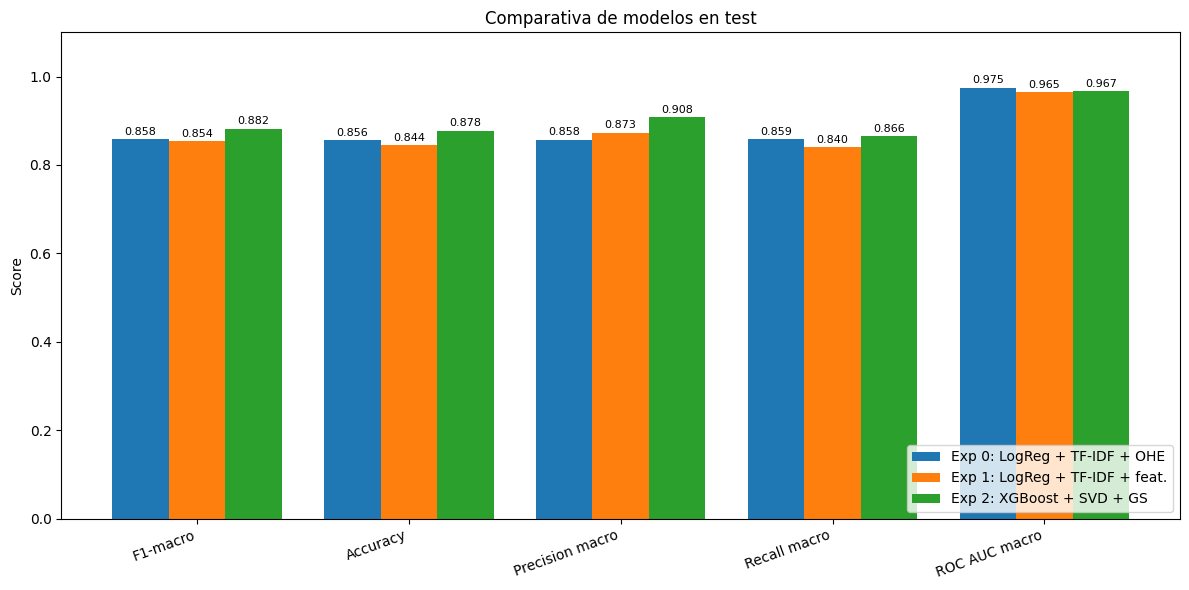

In [17]:
import matplotlib.pyplot as plt

fig_bar, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(df_comparativa.columns))
width = 0.8 / len(df_comparativa)

for i, (nombre, metricas) in enumerate(df_comparativa.iterrows()):
    offset = (i - len(df_comparativa) / 2 + 0.5) * width
    bars = ax.bar(x + offset, metricas.values, width, label=nombre)
    for bar, val in zip(bars, metricas.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f"{val:.3f}", ha="center", va="bottom", fontsize=8)

ax.set_ylabel("Score")
ax.set_title("Comparativa de modelos en test")
ax.set_xticks(x)
ax.set_xticklabels(df_comparativa.columns, rotation=20, ha="right")
ax.legend(loc="lower right")
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.show()

## 5. Matrices de confusión

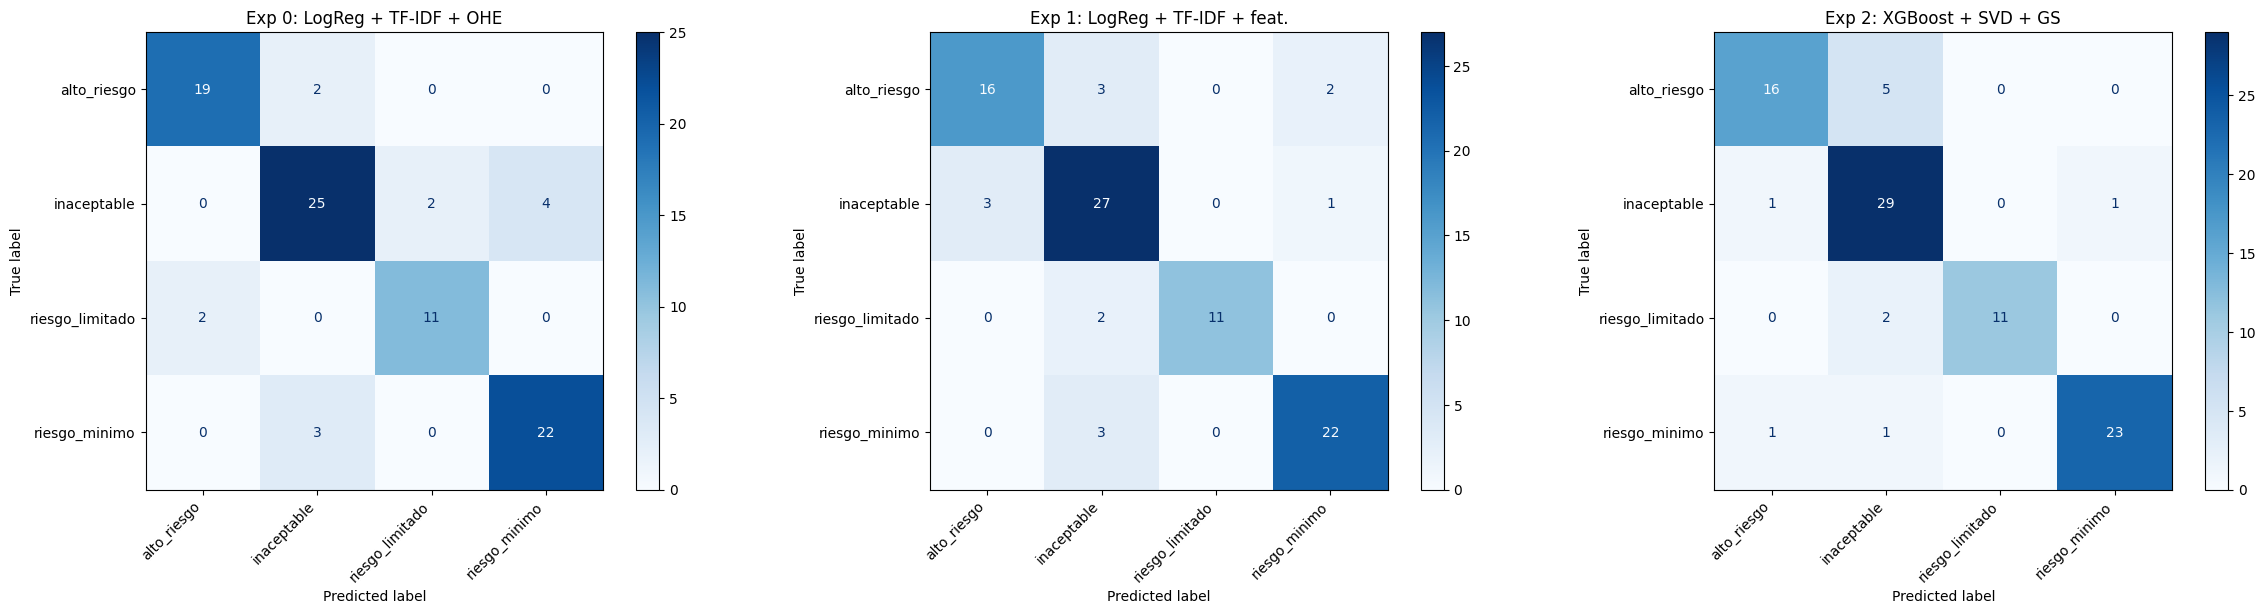

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

modelos_pred = {
    _exp0: y_pred_baseline,
    _exp1: y_pred_v2,
    _exp2: y_pred_xgb,
}

fig_cms, axes = plt.subplots(1, len(modelos_pred), figsize=(8 * len(modelos_pred), 6))

for ax, (nombre, y_pred) in zip(axes, modelos_pred.items()):
    cm = confusion_matrix(y_test, y_pred, labels=clases)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clases)
    disp.plot(ax=ax, cmap="Blues", values_format="d")
    ax.set_title(nombre)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.show()

## 6. Curvas ROC

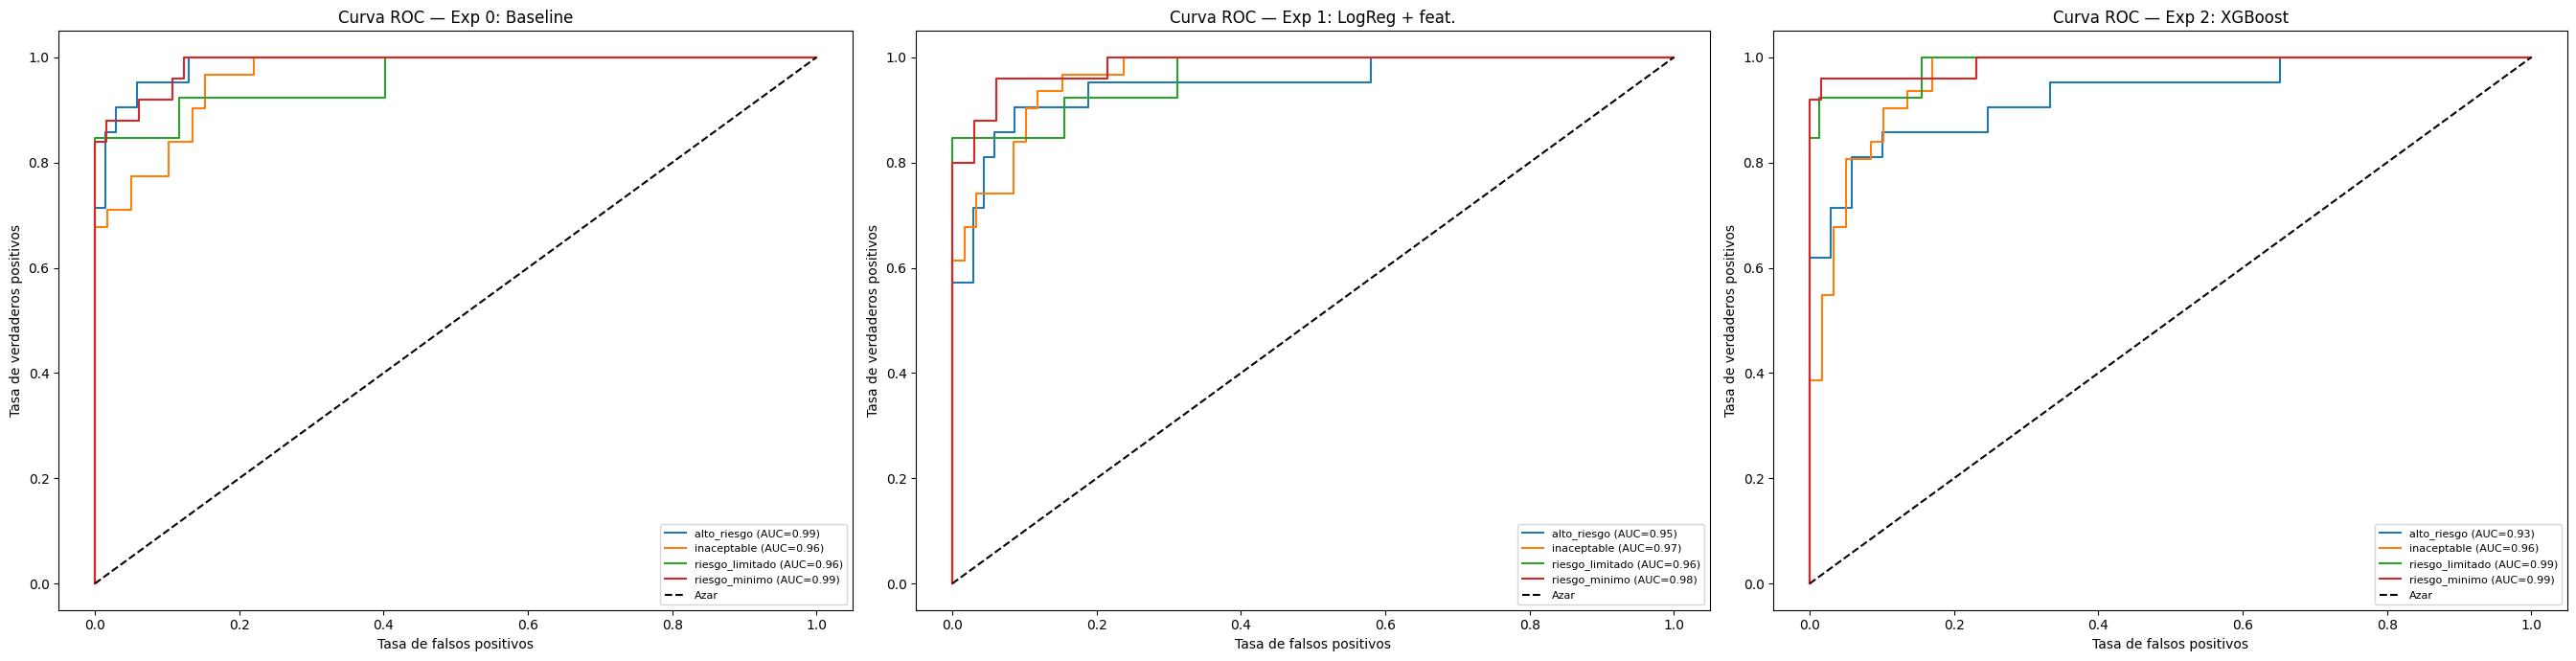

In [19]:
modelos_proba = {
    "Exp 0: Baseline": y_proba_baseline,
    "Exp 1: LogReg + feat.": y_proba_v2,
    "Exp 2: XGBoost": y_proba_xgb,
}

y_test_bin = label_binarize(y_test, classes=clases)

fig_roc, axes = plt.subplots(1, len(modelos_proba), figsize=(9 * len(modelos_proba), 7))

for ax, (nombre, y_proba) in zip(axes, modelos_proba.items()):
    for i, clase in enumerate(clases):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
        roc_auc_val = auc(fpr, tpr)
        ax.plot(fpr, tpr, label=f"{clase} (AUC={roc_auc_val:.2f})")

    ax.plot([0, 1], [0, 1], "k--", label="Azar")
    ax.set_xlabel("Tasa de falsos positivos")
    ax.set_ylabel("Tasa de verdaderos positivos")
    ax.set_title(f"Curva ROC — {nombre}")
    ax.legend(loc="lower right", fontsize=8)

plt.tight_layout()
plt.show()

## 7. Análisis de errores del mejor modelo

In [20]:
# Seleccionar el mejor modelo según F1-macro
mejor_nombre = df_comparativa["F1-macro"].idxmax()
print(f"Mejor modelo: {mejor_nombre} (F1-macro: {df_comparativa.loc[mejor_nombre, 'F1-macro']:.4f})\n")

mejor_pred = predicciones[mejor_nombre]["y_pred"]

df_errores = pd.DataFrame({
    "texto":             X_test_text.values,
    "etiqueta_real":     y_test.values,
    "etiqueta_predicha": mejor_pred,
})
df_errores = df_errores[df_errores["etiqueta_real"] != df_errores["etiqueta_predicha"]]

if df_errores.empty:
    print("No hay errores de clasificación en el conjunto de test.")
else:
    print(f"Total de errores: {len(df_errores)} de {len(y_test)} "
          f"({len(df_errores)/len(y_test)*100:.1f}%)\n")
    print("Confusiones más frecuentes:")
    confusiones = df_errores.groupby(
        ["etiqueta_real", "etiqueta_predicha"]
    ).size().sort_values(ascending=False)
    print(confusiones)
    print("\nEjemplos mal clasificados:")
    for _, row in df_errores.iterrows():
        print(f"  Real: {row['etiqueta_real']} | Predicho: {row['etiqueta_predicha']}")
        print(f"  Texto: {row['texto'][:120]}...")
        print()

Mejor modelo: Exp 2: XGBoost + SVD + GS (F1-macro: 0.8822)

Total de errores: 11 de 90 (12.2%)

Confusiones más frecuentes:
etiqueta_real    etiqueta_predicha
alto_riesgo      inaceptable          5
riesgo_limitado  inaceptable          2
inaceptable      alto_riesgo          1
                 riesgo_minimo        1
riesgo_minimo    alto_riesgo          1
                 inaceptable          1
dtype: int64

Ejemplos mal clasificados:
  Real: alto_riesgo | Predicho: inaceptable
  Texto: compañía seguro utilizar sistema inteligencia artificial rechazar automáticamente reclamación incidente relacionado salu...

  Real: alto_riesgo | Predicho: inaceptable
  Texto: empresa servicio legal utilizar sistema inteligencia artificial automatizar revisión contrato sistema basar dato persona...

  Real: alto_riesgo | Predicho: inaceptable
  Texto: compañía seguro utilizar sistema inteligencia artificial evaluar puntuación riesgo asegurado análisis dato personal esen...

  Real: inaceptable | Pred

## 8. Selección del mejor modelo

In [21]:
import json

print("=== RESUMEN FINAL ===\n")
print(df_comparativa.round(4).to_string())
print(f"\nModelo seleccionado: {mejor_nombre}")
print(f"Justificación: Mayor F1-macro en test ({df_comparativa.loc[mejor_nombre, 'F1-macro']:.4f})")
print("\nNota: F1-macro es la métrica principal porque trata todas las clases por igual,")
print("lo cual es importante en un dataset con clases ligeramente desbalanceadas.")

# Guardar la selección para que notebook 10 la consuma sin hardcodear nada.
# Solo se incluyen campos serializables a JSON (sin modelo, X_test ni label_encoder).
mejor_metricas = df_comparativa.loc[mejor_nombre]
cfg = MODELO_REGISTRY[mejor_nombre]
seleccion = {
    "nombre":                mejor_nombre,
    "model_file":            cfg["model_file"],
    "tfidf_file":            cfg["tfidf_file"],
    "model_type":            cfg["model_type"],
    "experimento":           cfg["experimento"],
    "needs_manual_features": cfg["needs_manual_features"],
    "test_f1_macro":         round(float(mejor_metricas["F1-macro"]), 4),
    "test_accuracy":         round(float(mejor_metricas["Accuracy"]), 4),
    "test_roc_auc":          round(float(mejor_metricas["ROC AUC macro"]), 4),
    "criterio":              "Mayor F1-macro en test entre los 3 experimentos",
}

with open("model/mejor_modelo_seleccion.json", "w", encoding="utf-8") as f:
    json.dump(seleccion, f, indent=2, ensure_ascii=False)

print("\n✓ Selección guardada en model/mejor_modelo_seleccion.json")

=== RESUMEN FINAL ===

                                F1-macro  Accuracy  Precision macro  Recall macro  ROC AUC macro
Exp 0: LogReg + TF-IDF + OHE      0.8583    0.8556           0.8576        0.8593         0.9748
Exp 1: LogReg + TF-IDF + feat.    0.8537    0.8444           0.8734        0.8398         0.9655
Exp 2: XGBoost + SVD + GS         0.8822    0.8778           0.9078        0.8659         0.9668

Modelo seleccionado: Exp 2: XGBoost + SVD + GS
Justificación: Mayor F1-macro en test (0.8822)

Nota: F1-macro es la métrica principal porque trata todas las clases por igual,
lo cual es importante en un dataset con clases ligeramente desbalanceadas.

✓ Selección guardada en model/mejor_modelo_seleccion.json


## 9. Registro en MLflow

In [22]:
# ── MLflow (solo falla esta celda si el servidor no está disponible) ──
import mlflow
from functions import configure_mlflow, MLFLOW_EXPERIMENT

# Guardar gráficos localmente (no depende del servidor)
fig_bar.savefig("model/comparativa_barras.png", dpi=150, bbox_inches="tight")
fig_cms.savefig("model/matrices_confusion_comparativa.png", dpi=150, bbox_inches="tight")
fig_roc.savefig("model/curvas_roc_comparativa.png", dpi=150, bbox_inches="tight")

try:
    configure_mlflow()
    mlflow.set_experiment(MLFLOW_EXPERIMENT)

    with mlflow.start_run(run_name="comparativa_final"):
        for nombre, metricas in resultados.items():
            tag = nombre.split(":")[0].strip().replace(" ", "_").lower()
            for metrica, valor in metricas.items():
                mlflow.log_metric(f"{tag}_test_{metrica.lower().replace(' ', '_')}", valor)

        mlflow.log_param("mejor_modelo",        mejor_nombre)
        mlflow.log_param("criterio_seleccion",  "F1-macro")

        mlflow.log_artifact("model/comparativa_barras.png")
        mlflow.log_artifact("model/matrices_confusion_comparativa.png")
        mlflow.log_artifact("model/curvas_roc_comparativa.png")

        print("✓ Comparativa final registrada en MLflow")
        print(f"  Mejor modelo: {mejor_nombre}")
        print(f"  Run ID: {mlflow.active_run().info.run_id}")
except Exception as e:
    print(f"⚠ MLflow no disponible: {e}")

Password obtenida desde variable de entorno local.
MLflow configurado correctamente → https://18.201.64.41/


c:\Users\rammu\anaconda3\envs\venv_proyecto\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host '18.201.64.41'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
c:\Users\rammu\anaconda3\envs\venv_proyecto\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host '18.201.64.41'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
c:\Users\rammu\anaconda3\envs\venv_proyecto\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host '18.201.64.41'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
c:\Users\r

✓ Comparativa final registrada en MLflow
  Mejor modelo: Exp 2: XGBoost + SVD + GS
  Run ID: a0dc99393eaf4d29beba36cd746a40ab


c:\Users\rammu\anaconda3\envs\venv_proyecto\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host '18.201.64.41'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
